# 🔥 Stage 3B: Supervised Learning with Class Weighting

**Objective:** Fine-tune RoBERTa on the Kaggle Game Dataset (imbalanced) using **Class Weighting** to help the model learn underrepresented classes without dropping any samples.

**Dataset:** Kaggle Reddit Gaming Comments (~23k samples – keep original distribution)

**Method:** Weighted CrossEntropy Loss with **log-scaled class weights**  

**Formula:**  
w_i = 1 / log(1 + n_i)
where `n_i` is the number of samples in class i.  
Weights are normalized so that the sum equals 1.

---

## 📊 Pipeline

1. Load the Kaggle dataset (imbalanced – keep original distribution)  
2. Encode labels (`positive`, `neutral`, `negative`) → integers  
3. Tokenize text using `AutoTokenizer` (RoBERTa-Twitter)  
4. Create **Weighted CrossEntropy Loss** with log-scaled class weights  
5. Fine-tune RoBERTa-Twitter using a **Custom Trainer** applying weighted loss  
6. Evaluate on the test set (Accuracy, Weighted F1, Macro F1, Confusion Matrix)  

---

## 🎯 Key Highlights

- Handles mild to moderate class imbalance without losing data  
- Focuses on learning underrepresented classes  
- Log-scaled weights prevent extremely large values → more stable training  

---


#Environment Setup


In [1]:
# Install required packages
!pip install -q transformers torch datasets
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q tqdm

print("✅ Packages installed successfully!")


✅ Packages installed successfully!


#Import Libraries

In [2]:
# Ignore warnings for clean output
import warnings
warnings.filterwarnings('ignore')

import os
from transformers.utils import logging
logging.set_verbosity_error()
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import json
from google.colab import files

from transformers import DataCollatorWithPadding

# Core ML/Data Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from tqdm.auto import tqdm # Progress bar

# Hugging Face: Models, Tokenizer, and Training Framework
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    EvalPrediction
)

from datasets import Dataset

# Scikit-learn: Data splitting and Evaluation Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# Plotting Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Environment Check
print("🔥 PyTorch:", torch.__version__)
print("🤖 Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

🔥 PyTorch: 2.9.0+cu126
🤖 Device: Tesla T4


#Upload Dataset

In [3]:
# 📤 Colab file uploader
print("📤 Upload your Kaggle CSV file...")
uploaded = files.upload()

# Load the uploaded CSV into a Pandas DataFrame
csv_filename = list(uploaded.keys())[0]
df = pd.read_csv(csv_filename)

# Display dataset info
print("📊 Dataset loaded:", df.shape)
display(df.head())

📤 Upload your Kaggle CSV file...


Saving cleaned_comments.csv to cleaned_comments.csv
📊 Dataset loaded: (21821, 3)


,Unnamed: 0,comment,sentiment
0,0,dont think like game havent even played minute...,negative
1,1,leave farm smaller creature either wait help k...,negative
2,2,nothing beat feeling get see fall love like ye...,positive
3,3,also theyre made paper edit tried make gif fai...,negative
4,4,haha exactly brother tried get wow run raid ge...,positive


#Class Distribution


📊 Class distribution:
sentiment
positive    9777
neutral     8013
negative    4031
Name: count, dtype: int64
sentiment
positive    44.805463
neutral     36.721507
negative    18.473031
Name: count, dtype: float64


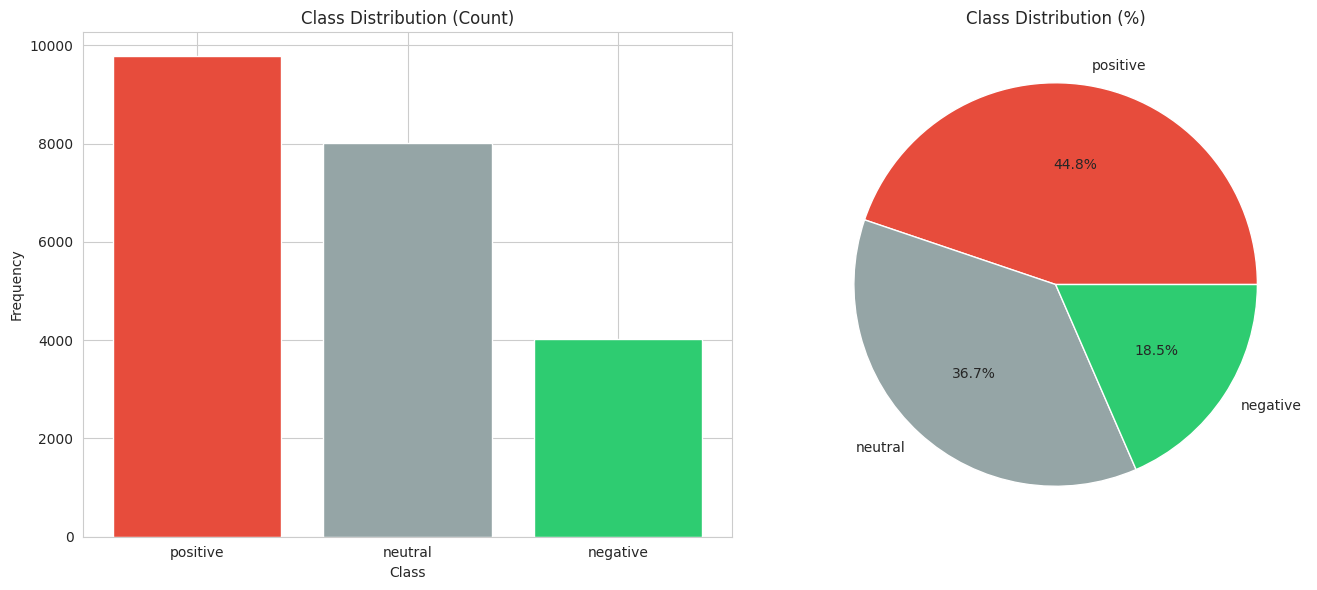


⚠️ Imbalance ratio: 2.43:1

✅ Dataset is IMBALANCED → Will use Focal Loss to handle this!


In [4]:

# ===== COLOR PALETTE =====
colors = ['#e74c3c', '#95a5a6', '#2ecc71']


# ===== CLASS COUNTS =====
label_col = "sentiment"
text_col = "comment"

# Ensure comment, label is string (e.g., "positive", "neutral", "negative")
df[label_col] = df[label_col].astype(str)
df[text_col] = df[text_col].astype(str)



class_counts = df[label_col].value_counts()

print("\n📊 Class distribution:")
print(class_counts)
print(class_counts / class_counts.sum() * 100)

# ===== PLOTTING =====
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].bar(class_counts.index, class_counts.values, color=colors[:len(class_counts)])
axes[0].set_title("Class Distribution (Count)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Frequency")

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    colors=colors[:len(class_counts)]
)
axes[1].set_title("Class Distribution (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# ===== IMBALANCE RATIO =====
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\n⚠️ Imbalance ratio: {imbalance_ratio:.2f}:1")
print("\n✅ Dataset is IMBALANCED → Will use Focal Loss to handle this!")


#Label Encoding


In [5]:
# Extract and sort all unique labels from the DataFrame.
unique_labels = sorted(df[label_col].unique())

# Create the label-to-ID (string to int) mapping for model training.
label2id = {l:i for i,l in enumerate(unique_labels)}
id2label = {i:l for l,i in label2id.items()}

# Add a new column with numerical IDs for classification tasks.
df['label_id'] = df[label_col].map(label2id)

print("📌 Label mapping:", label2id)

📌 Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


#Train/Val/Test split

In [6]:
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df['label_id'], random_state=42)

val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['label_id'], random_state=42)

print("📊 Dataset Split Summary")
print("-" * 50)
print(f"🟩 Training set:      {len(train_df):,} samples")
print(f"🟦 Validation set:    {len(val_df):,} samples")
print(f"🟥 Test set:          {len(test_df):,} samples")
print("-" * 50)
print(f"✅ Total:             {len(train_df) + len(val_df) + len(test_df):,} samples")
print(f"📎 Columns: {list(df.columns)}")


📊 Dataset Split Summary
--------------------------------------------------
🟩 Training set:      15,274 samples
🟦 Validation set:    3,273 samples
🟥 Test set:          3,274 samples
--------------------------------------------------
✅ Total:             21,821 samples
📎 Columns: ['Unnamed: 0', 'comment', 'sentiment', 'label_id']


#Model + Tokenizer

In [7]:
# Load tokenizer and model with custom label mapping
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# Check token lengths
comment_lengths = df[text_col].apply(lambda x: len(tokenizer.tokenize(x)))
print("Mean token length:", comment_lengths.mean())
print("Max token length:", comment_lengths.max())

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
).to("cuda" if torch.cuda.is_available() else "cpu")


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Mean token length: 12.8033545667018
Max token length: 1299


pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

In [8]:

# Tokenize text column
def tokenize_fn(examples):
    return tokenizer(examples[text_col], truncation=True, padding=True, max_length=512)

# Convert DataFrames → HF Datasets (rename label column)
train_ds = Dataset.from_pandas(train_df[[text_col, 'label_id']].rename(columns={'label_id': 'label'}))
val_ds   = Dataset.from_pandas(val_df[[text_col, 'label_id']].rename(columns={'label_id': 'label'}))
test_ds  = Dataset.from_pandas(test_df[[text_col, 'label_id']].rename(columns={'label_id': 'label'}))

# Apply tokenization
train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds   = val_ds.map(tokenize_fn, batched=True)
test_ds  = test_ds.map(tokenize_fn, batched=True)


Map:   0%|          | 0/15274 [00:00<?, ? examples/s]

Map:   0%|          | 0/3273 [00:00<?, ? examples/s]

Map:   0%|          | 0/3274 [00:00<?, ? examples/s]

#Class Weight Loss



In [9]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute log-scaled class weights
train_counts = train_df["label_id"].value_counts().sort_index()
weights = 1 / np.log1p(train_counts)
weights = weights / weights.sum()
class_weights = torch.tensor(weights.values, dtype=torch.float32).to(device)

# Weighted cross-entropy loss
class WeightedCELoss(nn.Module):
    def __init__(self, weights):
        super().__init__()
        self.weights = weights
    def forward(self, logits, labels):
        return F.cross_entropy(logits, labels, weight=self.weights)

ce_loss_fn = WeightedCELoss(class_weights)

# Trainer using weighted loss
class WeightedTrainer(Trainer):
    def __init__(self, loss_fn, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fn = loss_fn
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = self.loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss


#Train Model

In [10]:
def compute_metrics(eval_pred: EvalPrediction):
    """
    Compute Accuracy, F1 Weighted, and F1 Macro from prediction results.

    Args:
        eval_pred (EvalPrediction): An object containing logits (predictions) and label_ids (ground-truth labels).

    Returns:
        dict: A dictionary containing the calculated metrics.
    """

    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)

    f1_w = f1_score(labels, predictions, average="weighted")

    f1_m = f1_score(labels, predictions, average="macro")


    return {
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
    }

In [11]:
training_args = TrainingArguments(
    output_dir="./stage3_roberta_class_weight",  # folder for checkpoints
    num_train_epochs=4,                          # training epochs
    per_device_train_batch_size=16,              # train batch size
    per_device_eval_batch_size=32,               # eval batch size
    warmup_steps=500,                            # LR warmup
    learning_rate=1e-5,                          # base LR
    weight_decay=0.01,                           # L2 regularization
    logging_steps=50,                            # log frequency
    logging_dir="./logs",                        # optional, for TensorBoard
    eval_strategy="steps",                       # run eval by step
    eval_steps=200,                              # eval every 200 steps
    save_steps=200,                              # save every 200 steps
    save_total_limit=3,                          # max checkpoints to keep
    load_best_model_at_end=True,                 # restore best checkpoint
    metric_for_best_model="f1_macro",            # best model = highest F1-macro
    report_to="none",                            # disable W&B
    max_grad_norm=1.0                            # gradient clipping
)


In [12]:
# Initialize Trainer with weighted loss
trainer = WeightedTrainer(
    loss_fn=ce_loss_fn,                                           # custom weighted loss
    model=model,                                                  # RoBERTa model
    args=training_args,                                           # training arguments
    train_dataset=train_ds,                                       # training dataset
    eval_dataset=val_ds,                                          # validation dataset
    tokenizer=tokenizer,                                          # tokenizer for padding/encoding
    data_collator=DataCollatorWithPadding(tokenizer),             # dynamic padding
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)], # stop early after 3 bad evals
    compute_metrics=compute_metrics                               # function to compute metrics
)

# Start training
print("🔥 Training with CLASS WEIGHTING...")
train_result = trainer.train()


🔥 Training with CLASS WEIGHTING...
{'loss': 0.9677, 'grad_norm': 12.574145317077637, 'learning_rate': 9.800000000000001e-07, 'epoch': 0.05235602094240838}
{'loss': 0.8941, 'grad_norm': 16.98314666748047, 'learning_rate': 1.98e-06, 'epoch': 0.10471204188481675}
{'loss': 0.7679, 'grad_norm': 19.714990615844727, 'learning_rate': 2.9800000000000003e-06, 'epoch': 0.15706806282722513}
{'loss': 0.7909, 'grad_norm': 10.015859603881836, 'learning_rate': 3.980000000000001e-06, 'epoch': 0.2094240837696335}
{'eval_loss': 0.753963828086853, 'eval_accuracy': 0.6791934005499541, 'eval_f1_weighted': 0.680707258933873, 'eval_f1_macro': 0.6592625786163522, 'eval_runtime': 59.0697, 'eval_samples_per_second': 55.409, 'eval_steps_per_second': 1.744, 'epoch': 0.2094240837696335}
{'loss': 0.7305, 'grad_norm': 13.6477632522583, 'learning_rate': 4.980000000000001e-06, 'epoch': 0.2617801047120419}
{'loss': 0.7328, 'grad_norm': 11.081330299377441, 'learning_rate': 5.98e-06, 'epoch': 0.31413612565445026}
{'loss':

#EVALUATE + VISUALIZE


  Accuracy:    0.8189 (81.89%)
  F1 weighted: 0.8183 (81.83%)
  F1 macro:    0.7955 (79.55%)

               precision    recall  f1-score   support

    negative       0.69      0.72      0.71       605
     neutral       0.84      0.77      0.80      1202
    positive       0.85      0.90      0.88      1467

    accuracy                           0.82      3274
   macro avg       0.80      0.80      0.80      3274
weighted avg       0.82      0.82      0.82      3274



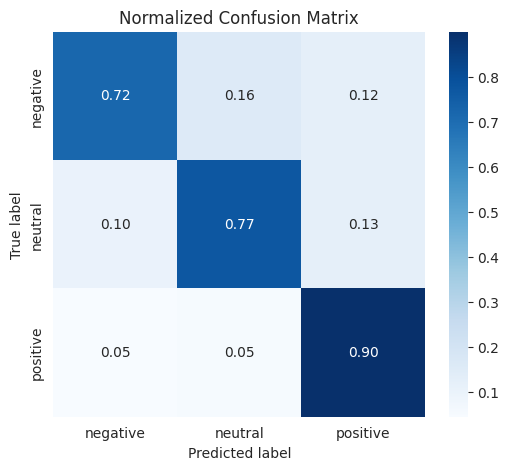

In [13]:
# Predict on test dataset
predictions = trainer.predict(test_ds)
pred_labels = np.argmax(predictions.predictions, axis=-1).astype(np.int64)
true_labels = test_df["label_id"].values.astype(np.int64)

acc = accuracy_score(true_labels, pred_labels)
f1 = f1_score(true_labels, pred_labels, average="weighted")
f1_macro = f1_score(true_labels, pred_labels, average="macro")

# Compute metrics
print(f"  Accuracy:    {acc:.4f} ({acc*100:.2f}%)")
print(f"  F1 weighted: {f1:.4f} ({f1*100:.2f}%)")
print(f"  F1 macro:    {f1_macro:.4f} ({f1_macro*100:.2f}%)")
print("\n", classification_report(true_labels, pred_labels, target_names=unique_labels))

# Confusion matrix normalized
cm = confusion_matrix(true_labels, pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=unique_labels, yticklabels=unique_labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Normalized Confusion Matrix')
plt.show()

#Save Results & Model

In [14]:
# Prepare results dictionary
results = {
    'stage': 3,
    'method': 'Class Weighting',
    'dataset': 'Kaggle Game Reviews',
    'dataset_size': len(df),
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'model': MODEL_NAME,
    'epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size,
    'learning_rate': training_args.learning_rate,
    'metrics': {
        'accuracy': float(acc),
        'f1_weighted': float(f1),
        'f1_macro': float(f1_macro)
    },
    'class_weights': class_weights.cpu().tolist(),
    'class_distribution': df[label_col].value_counts().to_dict(),
    'training_time_seconds': train_result.metrics['train_runtime'],

}

# Save results to JSON
with open('stage3_classweight_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("💾 Results saved to: stage3_classweight_results.json")

# Save model & tokenizer
model_path = './stage3_roberta_class_weight_final'
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"💾 Model saved to: {model_path}")

# Download results JSON from Colab
print("📥 Downloading results...")
files.download('stage3_classweight_results.json')

print("\n✅ Stage 3 complete!")

💾 Results saved to: stage3_classweight_results.json
💾 Model saved to: ./stage3_roberta_class_weight_final
📥 Downloading results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Stage 3 complete!
